## Imports

In [160]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV, RepeatedKFold
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, mean_absolute_error
from sklearn.inspection import DecisionBoundaryDisplay

from scipy.stats import loguniform, uniform, randint

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
# Import datasets
df_credit = pd.read_csv('df_credit_clean.csv')
df_fred = pd.read_csv('df_fred_clean.csv')
df_fred_fdic = pd.read_csv('df_fred_fdic.csv')

# Homework 1

In [15]:
df_credit.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.783060,9592.486655,9.965326,0.218705,0.170248,0.176772,5.811194
std,6.210445,5.251787e+04,3.981709,6320.885127,4.470688,0.413374,0.106785,0.381481,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.490000,0.000000,0.090000,0.000000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.620000,0.000000,0.150000,0.000000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,0.000000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,1.000000,30.000000


In [ ]:
cred_X = df_credit[['person_age']]
cred_y = df_credit['loan_status']
cred_X = sm.add_constant(cred_X)
model = sm.OLS(cred_y, cred_X)
results = model.fit() 
print(results.params)
num = df_credit.select_dtypes('number').drop(columns='loan_status')
for i, col in enumerate(num.columns):
    print(col, " VIF: ", variance_inflation_factor(num, i))

const         0.258895
person_age   -0.001449
dtype: float64
person_age  VIF:  22.732324146319712
person_income  VIF:  4.476639275711802
person_emp_length  VIF:  2.586126652353673
loan_amnt  VIF:  8.02276474370382
loan_int_rate  VIF:  6.239979334651249
loan_percent_income  VIF:  7.958015991426539
cb_person_default_on_file  VIF:  1.36321406448349
cb_person_cred_hist_length  VIF:  7.040829911934637


In [208]:
cred_X = df_credit[['person_age']] ** 0.5
cred_X = sm.add_constant(cred_X)
model = sm.OLS(cred_y, cred_X)
results = model.fit() 
print(results.params) 
round(results.pvalues, 6)

const         0.314050
person_age   -0.018205
dtype: float64


const         0.000000
person_age    0.000014
dtype: float64

In [197]:
df_credit['age^2'] = df_credit['person_age'] 
num = df_credit.select_dtypes('number').drop(columns=['loan_status', 'person_age'])
for i, col in enumerate(num.columns):
    print(col, " VIF: ", variance_inflation_factor(num, i))

person_income  VIF:  4.476639275711802
person_emp_length  VIF:  2.586126652353673
loan_amnt  VIF:  8.022764743703828
loan_int_rate  VIF:  6.239979334651249
loan_percent_income  VIF:  7.958015991426532
cb_person_default_on_file  VIF:  1.36321406448349
cb_person_cred_hist_length  VIF:  7.040829911934637
age^2  VIF:  22.732324146319712


In [44]:
enc.drop(columns='loan_status')[enc.drop(columns='loan_status').columns]

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,21,9600,5.0,1000,11.14,0.10,0,2,False,False,...,False,False,False,False,True,False,False,False,False,False
1,25,9600,1.0,5500,12.87,0.57,0,3,True,False,...,True,False,False,False,False,True,False,False,False,False
2,23,65500,4.0,35000,15.23,0.53,0,2,False,False,...,True,False,False,False,False,True,False,False,False,False
3,24,54400,8.0,35000,14.27,0.55,1,4,False,False,...,True,False,False,False,False,True,False,False,False,False
4,21,9900,2.0,2500,7.14,0.25,0,2,False,False,...,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32404,57,53000,1.0,5800,13.16,0.11,0,30,True,False,...,False,True,False,False,False,True,False,False,False,False
32405,54,120000,4.0,17625,7.49,0.15,0,19,True,False,...,False,True,False,True,False,False,False,False,False,False
32406,65,76000,3.0,35000,10.99,0.46,0,28,False,False,...,False,False,False,False,True,False,False,False,False,False
32407,56,150000,5.0,15000,11.48,0.10,0,26,True,False,...,False,True,False,False,True,False,False,False,False,False


In [65]:
enc = pd.get_dummies(df_credit, dtype='float64')
cred_X = enc.drop(columns='loan_status')
cred_X = sm.add_constant(cred_X)
model = sm.OLS(cred_y, cred_X)
results = model.fit() 
print(results.params) 

const                             1.525417e-01
person_age                       -6.253467e-04
person_income                     5.315436e-07
person_emp_length                -4.303294e-04
loan_amnt                        -1.549852e-05
loan_int_rate                     1.510009e-03
loan_percent_income               1.869487e+00
cb_person_default_on_file        -9.129298e-04
cb_person_cred_hist_length        2.679464e-04
person_home_ownership_MORTGAGE    3.391241e-02
person_home_ownership_OTHER       8.475065e-02
person_home_ownership_OWN        -9.140699e-02
person_home_ownership_RENT        1.252856e-01
loan_intent_DEBTCONSOLIDATION     7.540881e-02
loan_intent_EDUCATION            -2.196611e-02
loan_intent_HOMEIMPROVEMENT       7.375953e-02
loan_intent_MEDICAL               5.673995e-02
loan_intent_PERSONAL              4.500363e-03
loan_intent_VENTURE              -3.590083e-02
loan_grade_A                     -3.160217e-01
loan_grade_B                     -2.882985e-01
loan_grade_C 

In [164]:
consumer = ['IPCONGD', 'IPDCONGD', 'IPNCONGD', 'RPI', 'DPCERA3M086SBEA'] 
# IP=IP index. IP: Consumer Goods, IP: Durable Consumer Goods, IP: Nondurable Consumer Goods, Real Personal Income, Real personal consumption expenditures
nonconsumer = ['IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPMANSICS', 'IPFUELS', 'CUMFNS', 'HOUST']
# IP: Business Equipment, IP: Materials, IP: Durable Materials, IP: Manufacturing (SIC), IP: Fuels, Capacity Utilization: Manufacturing
targets = [['Noncurrent Loan Rate - Loans to Individuals'], ['Net Charge-Off Rate - All Loans'], ['DTCTHFNM']]

fred_fdic_X = df_fred_fdic[consumer]
fred_fdic_y = df_fred_fdic['Net Charge-Off Rate - All Loans']
fred_fdic_X = sm.add_constant(fred_fdic_X)
model = sm.OLS(fred_fdic_y, fred_fdic_X)
results = model.fit() 
print(results.params) 
# num = fred_X.select_dtypes('number').drop(columns='Net Charge-Off Rate - All Loans')
for i, col in enumerate(fred_fdic_X.columns):
    print(col, " VIF: ", variance_inflation_factor(fred_fdic_X, i))

const             -1.255218
IPCONGD           -0.527098
IPDCONGD           0.040910
IPNCONGD           0.485227
RPI               -0.000089
DPCERA3M086SBEA    0.033239
dtype: float64
const  VIF:  6439.4911199260705
IPCONGD  VIF:  4320.18972509955
IPDCONGD  VIF:  914.3745348869837
IPNCONGD  VIF:  3439.0701346487663
RPI  VIF:  36.412851376484355
DPCERA3M086SBEA  VIF:  30.150636736623575


In [ ]:
fred_X = df_fred.dropna()[[
 'CONSPI'
 ]]
fred_y = df_fred.dropna()['Year']
fred_X = sm.add_constant(fred_X)
fredmodel = sm.OLS(fred_y, fred_X)
results = fredmodel.fit() 
print(results.params) 

const     1937.252877
CONSPI       0.478341
dtype: float64


In [ ]:
scaler = StandardScaler()
dropped = df_fred.dropna(how='any').drop(columns=['Year', 'sasdate'])
df_fred_scaled = pd.DataFrame(scaler.fit_transform(dropped), index=dropped.index, columns=dropped.columns)
fred_X = df_fred_scaled[['M1SL', 'M2SL']]
# fred_X = df_fred_scaled['M1SL'] + df_fred_scaled['M2SL']
fred_y = df_fred.dropna(how='any')['Year']
fred_X = sm.add_constant(fred_X)
fredmodel = sm.OLS(fred_y, fred_X)
results = fredmodel.fit() 
print(results.params) 
results.pvalues

const    2000.454392
M1SL       -8.792083
M2SL       20.840953
dtype: float64


const     0.000000e+00
M1SL     3.545884e-105
M2SL     1.553659e-267
dtype: float64

In [128]:
money_credit_cols = ['DTCTHFNM',
 'DTCOLNVHFNM',
 'INVEST',
 'BUSLOANS',
 'NONREVSL',
 'CONSPI',
 'REALLN']
fred_X = pd.DataFrame(df_fred_scaled, index=dropped.index, columns=dropped.columns)[money_credit_cols]
fred_X = sm.add_constant(fred_X)
fredmodel = sm.OLS(fred_y, fred_X)
results = fredmodel.fit() 
print(results.params) 

const          2000.454392
DTCTHFNM          9.067327
DTCOLNVHFNM      -5.405552
INVEST           -7.074501
BUSLOANS          0.235913
NONREVSL         22.131402
CONSPI           -3.955808
REALLN           -1.446142
dtype: float64


In [211]:
fred_X = pd.DataFrame(df_fred_scaled, index=dropped.index, columns=dropped.columns)['BUSLOANS']
fred_X = sm.add_constant(fred_X)
fredmodel = sm.OLS(fred_y, fred_X)
results = fredmodel.fit() 
print(results.params) 
results.pvalues

const       2000.454392
BUSLOANS      13.548091
dtype: float64


const        0.000000e+00
BUSLOANS    6.589862e-286
dtype: float64

# Homework 2

In [77]:
def tune_regularized_regression(
    X_train, y_train,
    model_type="all",
    scale="both",
    cv=5,
    scoring="r2",
    n_iter=50,
    random_state=42
):
    """
    Hyperparameter tuning for Lasso, Ridge, and/or ElasticNet
    using RandomizedSearchCV with optional StandardScaler.

    Parameters
    ----------
    X_train      : array-like
    y_train      : array-like
    model_type   : "lasso" | "ridge" | "elasticnet" | "all"
    cv           : int
    scoring      : str
    n_iter       : int — number of parameter samples per variant
    random_state : int

    Returns
    -------
    tuning_results : dict  { variant_name: {"best_params": ..., "best_score": ..., "search": ...} }
    """

    # ── Parameter search spaces ────────────────────────────────────────────
    # loguniform samples alpha on a log scale — much better than uniform
    # since regularization strength spans several orders of magnitude
    param_grids = {
        "lasso": {
            "model__alpha":    loguniform(1e-4, 1e2),   # 0.0001 → 100
        },
        "ridge": {
            "model__alpha":    loguniform(1e-4, 1e2),
        },
        "elasticnet": {
            "model__alpha":    loguniform(1e-4, 1e2),
            "model__l1_ratio": uniform(0.01, 0.98),     # 0.01 → 0.99 (exclusive endpoints)
        },
    }

    model_registry = {
        "lasso":      Lasso(),
        "ridge":      Ridge(),
        "elasticnet": ElasticNet(),
    }

    models    = model_registry if model_type == "all" \
                else {model_type: model_registry[model_type]}

    tuning_results = {}
    summary_rows   = []

    for name, model in models.items():
        variant = f"{name}_{'scaled'}"

        # ── Build pipeline ─────────────────────────────────────────────
        steps = []
        steps.append(("scaler", StandardScaler()))
        steps.append(("model", model))
        pipe = Pipeline(steps)

        # ── RandomizedSearchCV ─────────────────────────────────────────
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grids[name],
            n_iter=n_iter,
            cv=cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=-1,              # use all cores
            return_train_score=True
        )
        search.fit(X_train, y_train)

        tuning_results[variant] = {
            "best_params": search.best_params_,
            "best_score":  search.best_score_,
            "search":      search,           # full search object if you need cv_results_
        }

        summary_rows.append({
            "variant":     variant,
            "best_score":  round(search.best_score_, 4),
            **{k.replace("model__", ""): round(v, 6) if isinstance(v, float) else v
                for k, v in search.best_params_.items()}
        })

    # ── Print ranked summary ───────────────────────────────────────────────
    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values("best_score", ascending=False)
        .reset_index(drop=True)
    )
    summary_df.index += 1
    summary_df.index.name = "rank"

    print("\n── Tuning Results (ranked by best CV score) ─────────────────")
    print(summary_df.to_string())
    print()

    for variant, res in tuning_results.items():
        print(f"  {variant}")
        for param, val in res["best_params"].items():
            clean = param.replace("model__", "")
            print(f"    {clean:12s}: {val:.6f}" if isinstance(val, float) else f"    {clean:12s}: {val}")
        print(f"    {'best_score':12s}: {res['best_score']:.4f}\n")

    return tuning_results, summary_df

In [72]:
def apply_regularized_regression(
    X_train, y_train, X_test=None, y_test=None,
    alpha=1.0,
    l1_ratio=0.5,            # ElasticNet only: mix between Lasso (1) and Ridge (0)
    model_type="all",        # "lasso", "ridge", "elasticnet", or "all"
    scale="both",            # True, False, or "both"
    cv=5,
    scoring="r2",
    plot=True,
    title=None
):
    """
    Fit Lasso, Ridge, and/or ElasticNet with optional StandardScaler,
    then visualize and rank results by CV mean and std.

    Parameters
    ----------
    X_train    : array-like
    y_train    : array-like
    X_test     : array-like, optional
    y_test     : array-like, optional
    alpha      : float — regularization strength
    l1_ratio   : float — ElasticNet mixing param (0=Ridge, 1=Lasso)
    model_type : "lasso" | "ridge" | "elasticnet" | "all"
    scale      : bool | "both"
    cv         : int
    scoring    : str — sklearn scoring metric
    plot       : bool — whether to render comparison visuals

    Returns
    -------
    results : dict, ranked_df : pd.DataFrame
    """
    import pandas as pd

    model_registry = {
        "lasso":      Lasso(alpha=alpha),
        "ridge":      Ridge(alpha=alpha),
        "elasticnet": ElasticNet(alpha=alpha, l1_ratio=l1_ratio),
    }

    models = model_registry if model_type == "all" \
             else {model_type: model_registry[model_type]}

    scale_opts = [True, False] if scale == "both" else [scale]
    results = {}

    for name, model in models.items():
        for use_scaler in scale_opts:
            variant = f"{name}_{'scaled' if use_scaler else 'unscaled'}"

            steps = []
            if use_scaler:
                steps.append(("scaler", StandardScaler()))
            steps.append(("model", model))

            pipe = Pipeline(steps)
            pipe.fit(X_train, y_train)
            cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring)

            entry = {
                "model":     pipe,
                "cv_scores": cv_scores,
                "cv_mean":   cv_scores.mean(),
                "cv_std":    cv_scores.std(),
            }
            if X_test is not None:
                entry["predictions"] = pipe.predict(X_test)

            results[variant] = entry

    # ── Ranked summary table ───────────────────────────────────────────────
    ranked_df = (
        pd.DataFrame([
            {"variant": k, "cv_mean": v["cv_mean"], "cv_std": v["cv_std"]}
            for k, v in results.items()
        ])
        .sort_values(["cv_mean", "cv_std"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_df.index += 1  # rank starts at 1
    ranked_df.index.name = "rank"

    print("\n── Ranked Results ──────────────────────────────────────")
    print(ranked_df.to_string())

    # ── Visuals ────────────────────────────────────────────────────────────
    if plot:
        variants   = [r["variant"] for _, r in ranked_df.iterrows()]
        means      = [results[v]["cv_mean"] for v in variants]
        stds       = [results[v]["cv_std"]  for v in variants]
        cv_scores  = [results[v]["cv_scores"] for v in variants]

        # colour by model family
        palette = {"lasso": "#4C72B0", "ridge": "#DD8452", "elasticnet": "#55A868"}
        colors  = [palette[v.split("_")[0]] for v in variants]

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(
            f"{title} Regularized Regression Comparison  (α={alpha}, cv={cv}, scoring={scoring})",
            fontsize=13, fontweight="bold", y=1.02
        )

        # ── 1. CV mean ± std bar chart ─────────────────────────────────────
        ax = axes[0]
        bars = ax.barh(variants[::-1], means[::-1], xerr=stds[::-1],
                       color=colors[::-1], edgecolor="white",
                       error_kw=dict(ecolor="black", capsize=4, linewidth=1.2))
        ax.set_xlabel(scoring)
        ax.set_xlim(0, 1)
        ax.set_title("CV Mean ± Std (ranked)")
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        for bar, mean in zip(bars, means[::-1]):
            ax.text(bar.get_width() + max(stds) * 0.05,
                    bar.get_y() + bar.get_height() / 2 + 0.04,
                    f"{mean:.4f}", va="center", fontsize=8)
        ax.grid(axis="x", linestyle="--", alpha=0.4)

        # ── 2. Std (stability) bar chart ──────────────────────────────────
        ax = axes[1]
        ax.barh(variants[::-1], stds[::-1], color=colors[::-1], edgecolor="white")
        ax.tick_params(axis='y', labelrotation=45) 
        ax.set_xlabel("CV Std  (lower = more stable)")
        ax.set_title("CV Std  (stability, ranked)")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        for i, std in enumerate(stds[::-1]):
            ax.text(std + max(stds) * 0.01, i, f"{std:.4f}", va="center", fontsize=8)

        # ── 3. Per-fold score distribution (box plot) ─────────────────────
        ax = axes[2]
        bp = ax.boxplot(
            cv_scores, vert=True, patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            labels=variants
        )
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_ylabel(scoring)
        ax.set_title("Per-fold Score Distribution")
        ax.set_xticklabels(variants, rotation=30, ha="right", fontsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        # ── 4. Predictions vs. Actuals (Overfitting) line graph ───────────
        if X_test is not None and y_test is not None:
            n_variants = len(variants)
            n_cols = 3
            n_rows = int(np.ceil(n_variants / n_cols))

            fig2, axes2 = plt.subplots(n_rows, n_cols,
                                       figsize=(5 * n_cols, 4 * n_rows))
            axes2 = np.array(axes2).flatten()
            fig2.suptitle(f"{title} Predictions vs. Actuals by Variant", fontsize=13,
                          fontweight="bold")

            for i, variant in enumerate(variants):
                ax2 = axes2[i]
                preds  = results[variant]["predictions"]
                color  = palette[variant.split("_")[0]]

                ax2.scatter(y_test, preds, color=color, alpha=0.6,
                            edgecolors="white", linewidths=0.5)

                # perfect-prediction reference line
                lo = min(y_test.min(), preds.min())
                hi = max(y_test.max(), preds.max())
                ax2.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="Perfect fit")

                ax2.set_title(variant, fontsize=9)
                ax2.set_xlabel("Actuals",      fontsize=8)
                ax2.set_ylabel("Predictions",  fontsize=8)
                ax2.legend(fontsize=7)
                ax2.grid(linestyle="--", alpha=0.3)

            # hide any unused subplots
            for j in range(i + 1, len(axes2)):
                axes2[j].set_visible(False)

            fig2.tight_layout()
            plt.show()

        
        # ── Legend ────────────────────────────────────────────────────────
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=c, label=m.title())
                           for m, c in palette.items()]
        fig.legend(handles=legend_elements, loc="lower center",
                   ncol=3, bbox_to_anchor=(0.5, -0.08), frameon=False)

        plt.tight_layout()
        plt.show()

    return results, ranked_df

In [187]:
cred_X = pd.get_dummies(df_credit).drop(columns=['loan_status', 'loan_amnt'])
cred_y = df_credit['loan_amnt']
cred_X_train, cred_X_test, cred_y_train, cred_y_test = train_test_split(cred_X, cred_y, test_size=0.3, random_state=1) 
el_net = ElasticNet(alpha=0.009669, l1_ratio=0.072287)
el_net.fit(cred_X, cred_Y)
pd.DataFrame([el_net.feature_names_in_, el_net.coef_], index=['features', 'coefficients']).T.sort_values(by='coefficients')

,features,coefficients
17,loan_grade_A,-0.199777
18,loan_grade_B,-0.18173
19,loan_grade_C,-0.15611
9,person_home_ownership_OWN,-0.071583
16,loan_intent_VENTURE,-0.05452
12,loan_intent_EDUCATION,-0.042811
15,loan_intent_PERSONAL,-0.015477
2,person_emp_length,-0.001851
0,person_age,-0.000808
7,person_home_ownership_MORTGAGE,-0.000448



── Tuning Results (ranked by best CV score) ─────────────────
                variant  best_score      alpha  l1_ratio
rank                                                    
1     elasticnet_scaled      0.6082   0.009669  0.072287
2          lasso_scaled      0.6081   1.274671       NaN
3          ridge_scaled      0.6081  65.987111       NaN

  lasso_scaled
    alpha       : 1.274671
    best_score  : 0.6081

  ridge_scaled
    alpha       : 65.987111
    best_score  : 0.6081

  elasticnet_scaled
    alpha       : 0.009669
    l1_ratio    : 0.072287
    best_score  : 0.6082



C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.438e+10, tolerance: 9.046e+07
  model = cd_fast.enet_coordinate_descent(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.101e+10, tolerance: 7.217e+07
  model = cd_fast.enet_coordinate_descent(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 



── Ranked Results ──────────────────────────────────────
                variant  cv_mean  cv_std
rank                                    
1          lasso_scaled      NaN     NaN
2          ridge_scaled      NaN     NaN
3     elasticnet_scaled      NaN     NaN


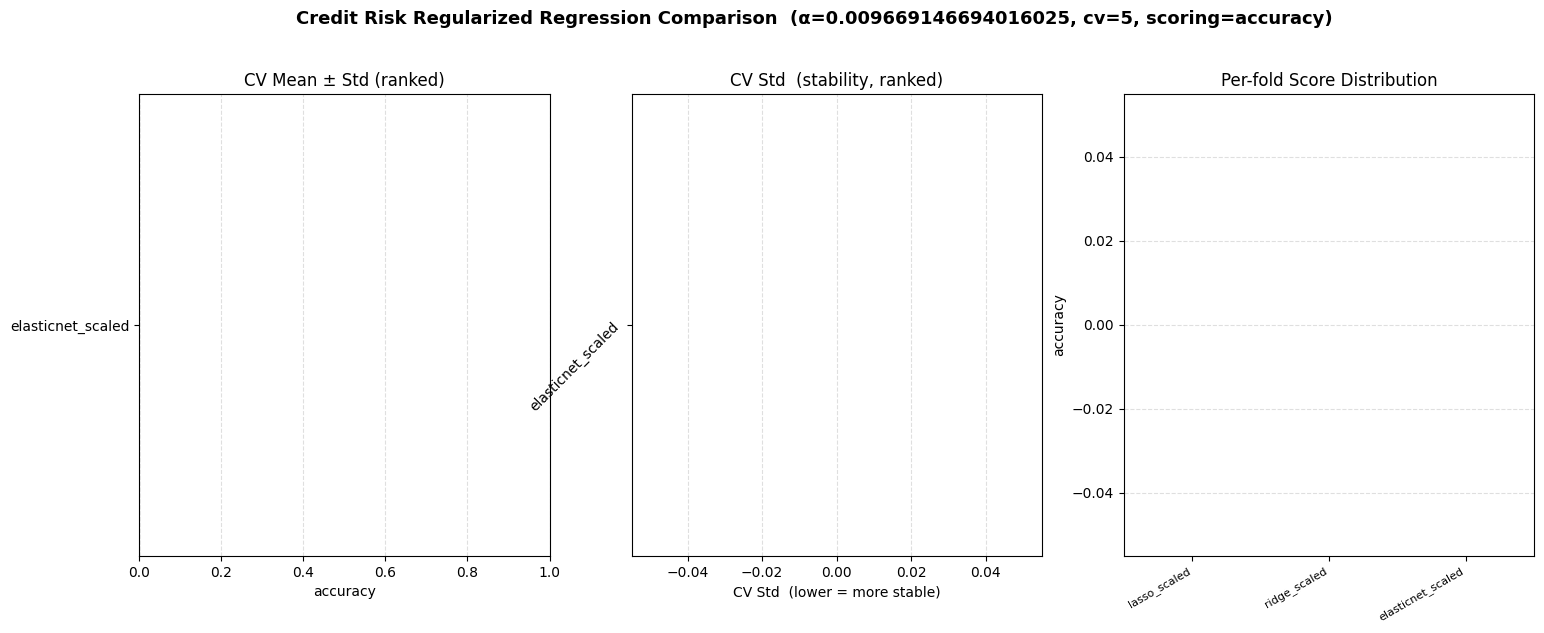

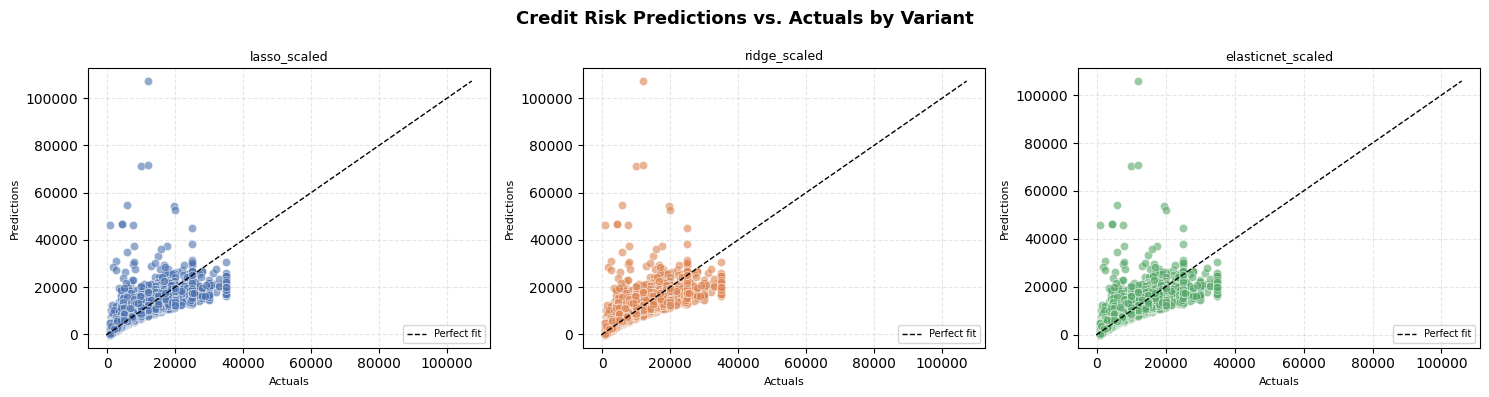

<Figure size 640x480 with 0 Axes>

({'lasso_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()),
                   ('model', Lasso(alpha=0.009669146694016025))]),
   'cv_scores': array([nan, nan, nan, nan, nan]),
   'cv_mean': nan,
   'cv_std': nan,
   'predictions': array([15968.30989955, 12860.80368408, 19220.24764836, ...,
           6124.38418571,   202.5966624 , 11378.63453653])},
  'ridge_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()),
                   ('model', Ridge(alpha=0.009669146694016025))]),
   'cv_scores': array([nan, nan, nan, nan, nan]),
   'cv_mean': nan,
   'cv_std': nan,
   'predictions': array([15968.29773534, 12860.85007626, 19220.2516231 , ...,
           6124.39927672,   202.64820418, 11378.74964777])},
  'elasticnet_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()),
                   ('model',
                    ElasticNet(alpha=0.009669146694016025,
                               l1_ratio=0.07228718328030316))]),
   'cv_scores': array([nan, nan, n

In [86]:
cred_X = pd.get_dummies(df_credit).drop(columns=['loan_status', 'loan_amnt'])
cred_y = df_credit['loan_amnt']
cred_X_train, cred_X_test, cred_y_train, cred_y_test = train_test_split(cred_X, cred_y, test_size=0.3, random_state=1)

# Step 1: tune to find best params
tuning_results, summary_df = tune_regularized_regression(
    cred_X_train, cred_y_train,
    model_type="all",
    scoring="r2",
    n_iter=50
)

# Step 2: feed best params into your original function
best = tuning_results["elasticnet_scaled"]["best_params"]

apply_regularized_regression(cred_X_train, cred_y_train, cred_X_test, cred_y_test, alpha = best["model__alpha"],
    l1_ratio = best.get("model__l1_ratio", 0.5), scale=True, title='Credit Risk', scoring='accuracy')

C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.015e+11, tolerance: 4.267e+09
  model = cd_fast.enet_coordinate_descent(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.886e+11, tolerance: 4.267e+09
  model = cd_fast.enet_coordinate_descent(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca


── Tuning Results (ranked by best CV score) ─────────────────
                variant  best_score      alpha  l1_ratio
rank                                                    
1          lasso_scaled      0.9701  62.200260       NaN
2          ridge_scaled      0.9701   0.054503       NaN
3     elasticnet_scaled      0.9701   0.000522   0.70898

  lasso_scaled
    alpha       : 62.200260
    best_score  : 0.9701

  ridge_scaled
    alpha       : 0.054503
    best_score  : 0.9701

  elasticnet_scaled
    alpha       : 0.000522
    l1_ratio    : 0.708980
    best_score  : 0.9701


── Ranked Results ──────────────────────────────────────
                variant   cv_mean    cv_std
rank                                       
1     elasticnet_scaled  0.970066  0.004729
2          ridge_scaled  0.970047  0.004896
3          lasso_scaled  0.970044  0.004902


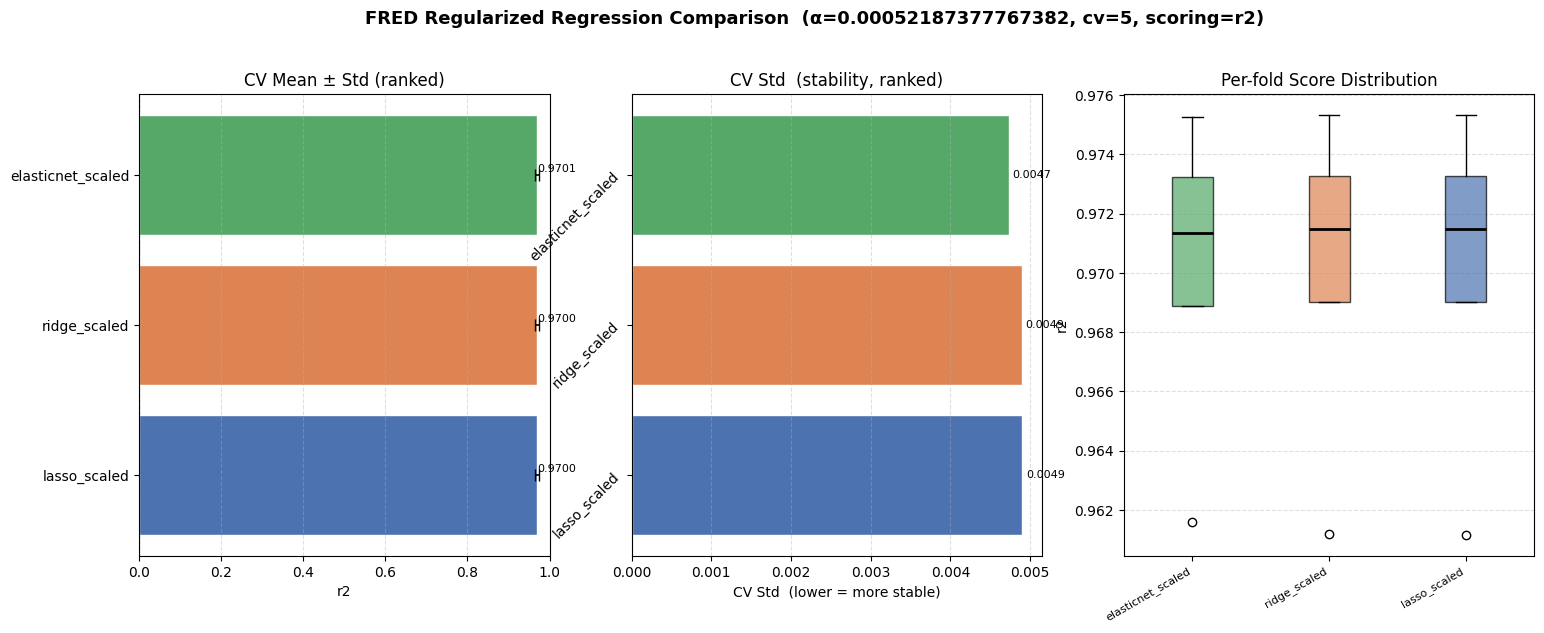

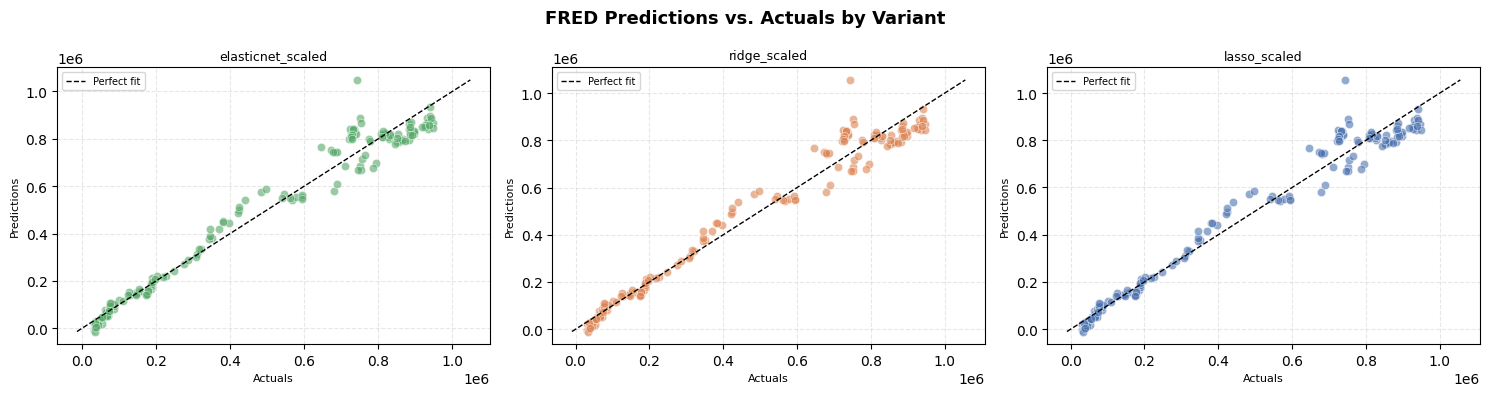

<Figure size 640x480 with 0 Axes>

({'lasso_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()),
                   ('model', Lasso(alpha=0.00052187377767382))]),
   'cv_scores': array([0.97532883, 0.97146878, 0.96116386, 0.97324982, 0.9690089 ]),
   'cv_mean': 0.9700440371421362,
   'cv_std': 0.0049023440865243045,
   'predictions': array([ 541449.61392372,  884778.87564243,  565192.49345012,
           859031.67873255,  498310.73136078,  119677.71862217,
           142928.90880736,   21138.67323944,  820147.0324916 ,
           820011.33533997,  553169.03380285,  802415.66864471,
           799733.26672138,  798384.19805121,  809159.77125456,
           485751.10294657,  572750.98967721,  932082.12717982,
            50518.95831672,   30110.00052901,  378448.1406116 ,
           153115.48707047,  870744.60613665,   76561.08131927,
           828645.43189533,  156393.62707163,  828203.32025601,
           790856.0504386 ,  895207.53046129,  220336.28457193,
           686260.11048282,   -3599.88878844,  210

In [84]:
fred_X = df_fred.dropna(how='any')[['HOUSTS', 'HOUST', 'HOUSTW', 'IPDCONGD', 'HOUSTMW', 
'HOUSTNE', 'IPMAT', 'IPDMAT', 'IPFUELS', 'IPNCONGD', 'RPI']]
fred_y = df_fred.dropna(how='any')['DTCTHFNM']
fred_X_train, fred_X_test, fred_y_train, fred_y_test = train_test_split(fred_X, fred_y, test_size=0.3, random_state=1)

tuning_results, summary_df = tune_regularized_regression(
    fred_X_train, fred_y_train,
    model_type="all",
    scoring="r2",
    n_iter=50
)

# Step 2: feed best params into your original function
best_fred = tuning_results["elasticnet_scaled"]["best_params"]

apply_regularized_regression(fred_X_train, fred_y_train, fred_X_test, fred_y_test, scale=True, alpha = best_fred["model__alpha"],
    l1_ratio = best_fred.get("model__l1_ratio", 0.5), title='FRED')

C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.685e-04, tolerance: 1.745e-04
  model = cd_fast.enet_coordinate_descent(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.252e-04, tolerance: 2.830e-04
  model = cd_fast.enet_coordinate_descent(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca


── Ranked Results ──────────────────────────────────────
                  variant     cv_mean      cv_std
rank                                             
1          lasso_unscaled -214.610814  415.954098
2     elasticnet_unscaled -395.432096  779.452311
3          ridge_unscaled -438.555252  796.939052


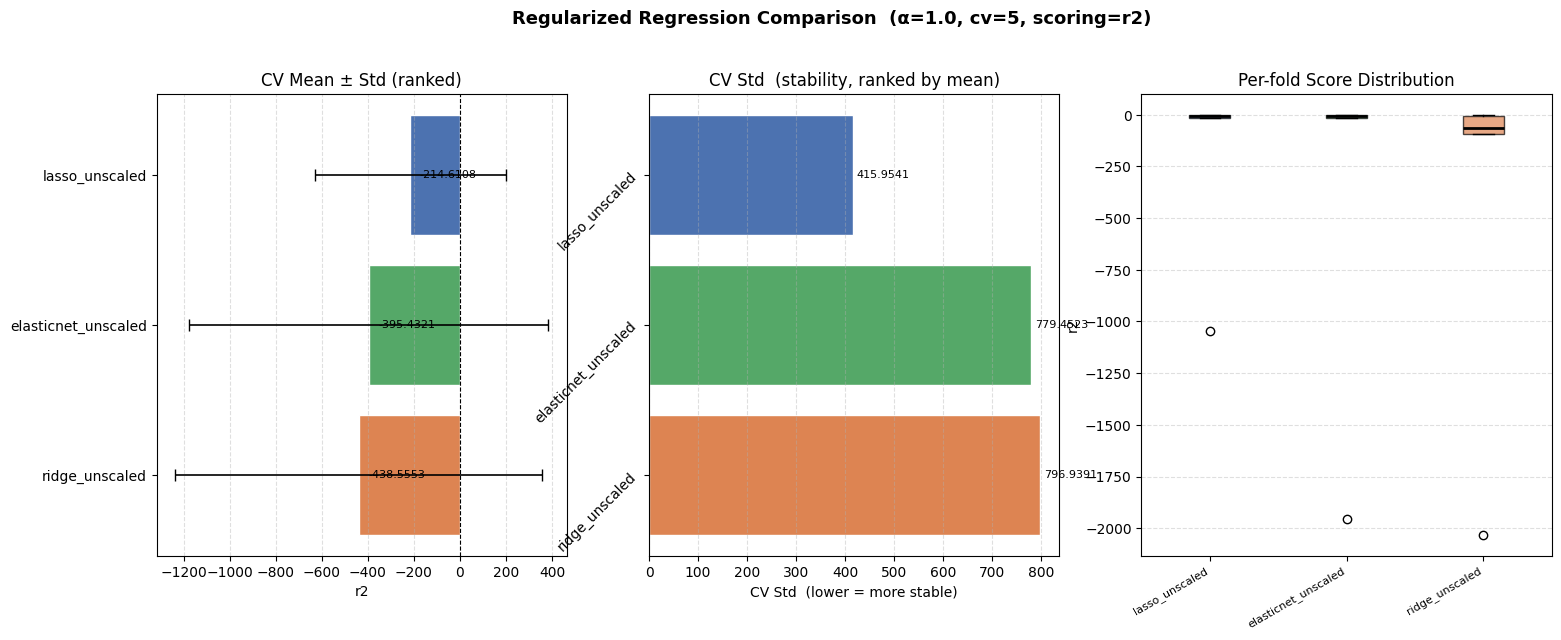

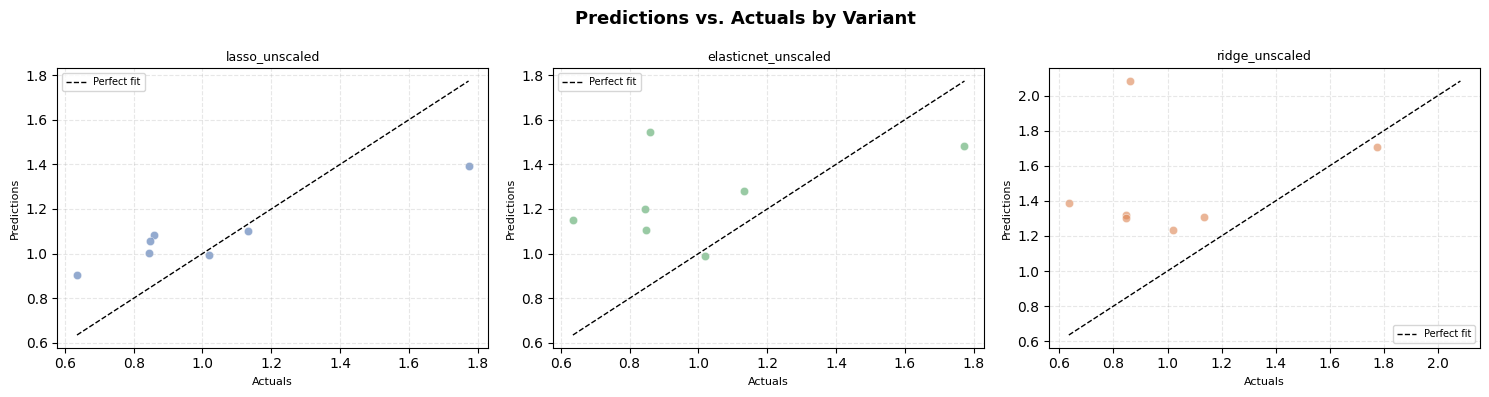

<Figure size 640x480 with 0 Axes>


── Ranked Results ──────────────────────────────────────
                variant   cv_mean    cv_std
rank                                       
1          lasso_scaled -4.518161  6.987993
2     elasticnet_scaled -4.518161  6.987993
3          ridge_scaled -6.452164  7.543431


C:\Users\romus\AppData\Local\Temp\ipykernel_27704\1575314203.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


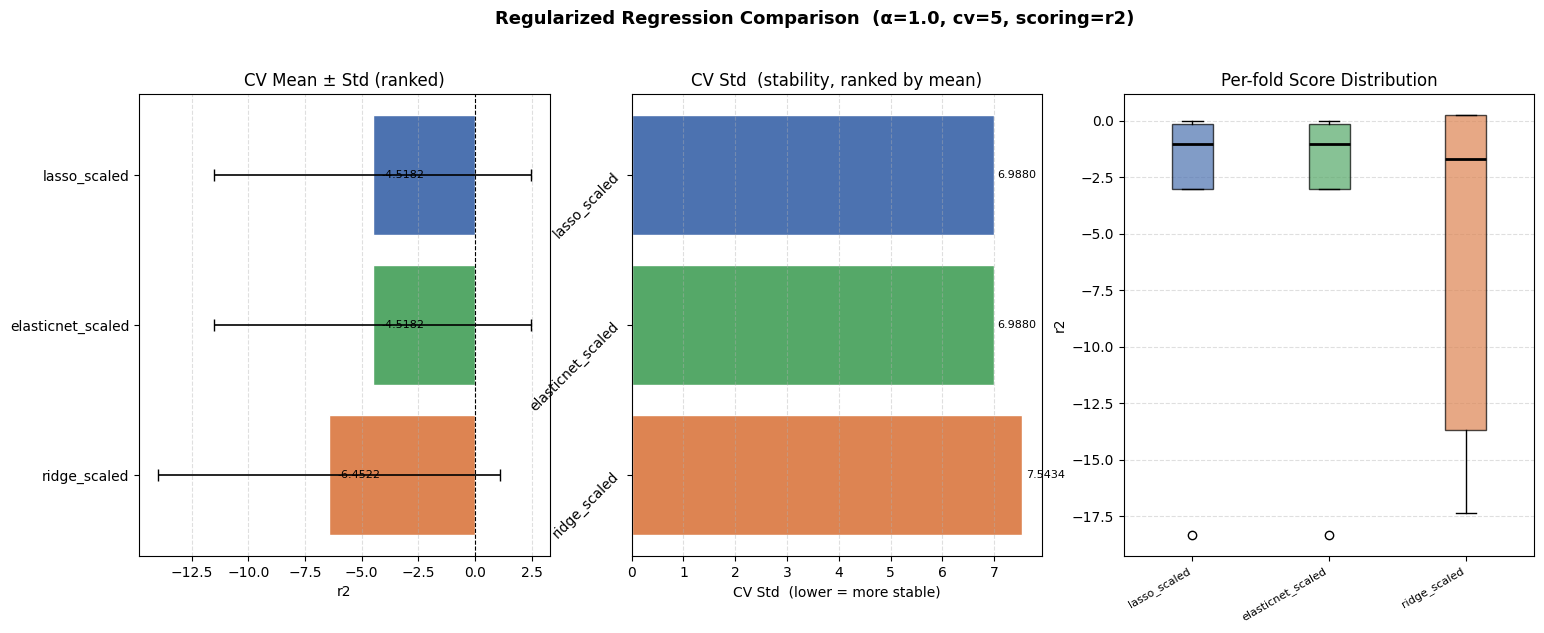

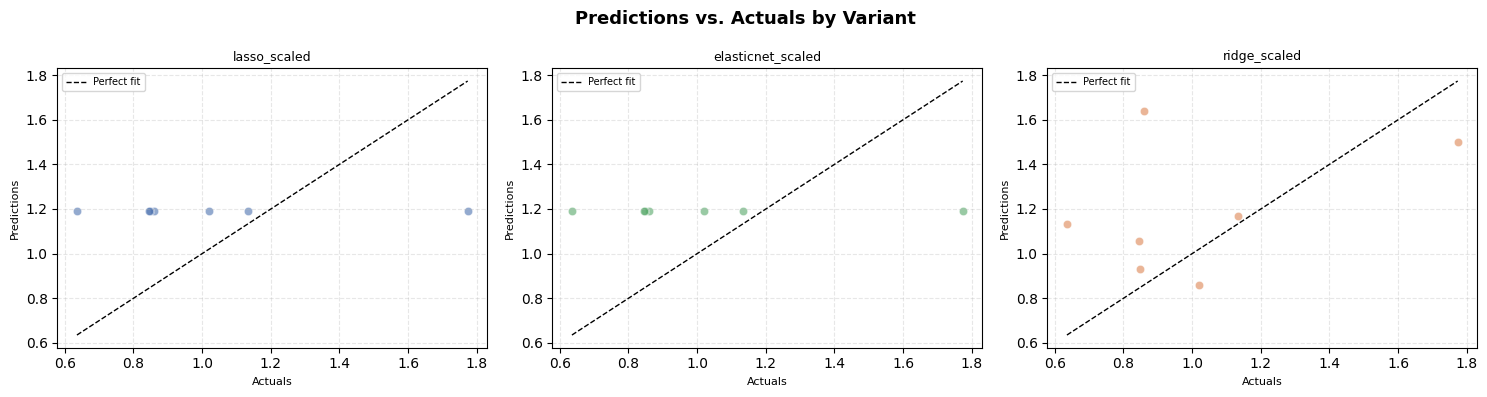

<Figure size 640x480 with 0 Axes>

({'lasso_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()), ('model', Lasso())]),
   'cv_scores': array([-3.04611794e+00, -1.04866996e+00, -3.47689718e-04, -1.83254349e+01,
          -1.70233628e-01]),
   'cv_mean': -4.518160827343353,
   'cv_std': 6.987992579298259,
   'predictions': array([1.19208129, 1.19208129, 1.19208129, 1.19208129, 1.19208129,
          1.19208129, 1.19208129])},
  'ridge_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())]),
   'cv_scores': array([  0.25656162, -13.69416389,  -1.69760807, -17.381756  ,
            0.25614392]),
   'cv_mean': -6.452164481996446,
   'cv_std': 7.5434307894139625,
   'predictions': array([1.63847285, 0.93198035, 1.50098603, 1.17010755, 1.05646928,
          0.85720202, 1.13365207])},
  'elasticnet_scaled': {'model': Pipeline(steps=[('scaler', StandardScaler()), ('model', ElasticNet())]),
   'cv_scores': array([-3.04611794e+00, -1.04866996e+00, -3.47689718e-04, -1.83254349e+01,
         

In [ ]:
fred_X = df_fred_fdic.dropna(how='any')[['HOUSTS', 'HOUST', 'HOUSTW', 'IPDCONGD', 'HOUSTMW', 'HOUSTNE', 'IPMAT', 'IPDMAT', 'IPFUELS', 'IPNCONGD', 'RPI']]
fred_y = df_fred_fdic.dropna(how='any')['Noncurrent Loan Rate - Loans to Individuals']
fred_X_train, fred_X_test, fred_y_train, fred_y_test = train_test_split(fred_X, fred_y, test_size=0.3, random_state=1)
apply_regularized_regression(fred_X_train, fred_y_train, fred_X_test, fred_y_test, scale=True)

# Homework 3

In [45]:
cred_X = df_credit.drop(columns='loan_status')
cred_y = df_credit['loan_status']

In [4]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# --- Auto-detect task type ---
def is_classification(y, threshold=10):
    return y.nunique() <= threshold or y.dtype == 'object'

# --- Encode target if categorical ---
def encode_target(y):
    if y.dtype == 'object' or str(y.dtype) == 'category':
        le = LabelEncoder()
        return pd.Series(le.fit_transform(y), index=y.index), True
    return y, is_classification(y)

# --- Encode features ---
def encode_features(X):
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    return X.select_dtypes(include='number')

# --- Forward Selection ---
def forward_selection(X, y, clf=False, max_features=None):
    remaining = list(X.columns)
    selected = []
    best_score = -np.inf
    max_features = max_features or len(remaining)
    scoring = 'accuracy' if clf else 'r2'
    model_cls = LogisticRegression(max_iter=1000) if clf else LinearRegression()

    while remaining and len(selected) < max_features:
        scores = {}
        for col in remaining:
            cols = selected + [col]
            score = cross_val_score(model_cls, X[cols], y, cv=5, scoring=scoring).mean()
            scores[col] = score
        best_col = max(scores, key=scores.get)
        if scores[best_col] > best_score:
            best_score = scores[best_col]
            selected.append(best_col)
            remaining.remove(best_col)
        else:
            break
    return selected

# --- Backward Selection ---
def backward_selection(X, y, clf=False):
    selected = list(X.columns)
    scoring = 'accuracy' if clf else 'r2'
    model_cls = LogisticRegression(max_iter=1000) if clf else LinearRegression()

    while len(selected) > 1:
        scores = {}
        for col in selected:
            cols = [c for c in selected if c != col]
            score = cross_val_score(model_cls, X[cols], y, cv=5, scoring=scoring).mean()
            scores[col] = score
        drop_col = max(scores, key=scores.get)
        baseline = cross_val_score(model_cls, X[selected], y, cv=5, scoring=scoring).mean()
        if scores[drop_col] >= baseline:
            selected.remove(drop_col)
        else:
            break
    return selected

# --- PCR ---
def run_pcr(X, y, clf=False, n_components=None):
    n_components = n_components or min(len(X.columns), 12)
    model_cls = LogisticRegression(max_iter=1000) if clf else LinearRegression()
    scoring = 'accuracy' if clf else 'r2'
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
        ('reg', model_cls)
    ])
    score = cross_val_score(pipe, X, y, cv=5, scoring=scoring).mean()
    pipe.fit(X, y)
    return pipe, score

# --- PLSR (regression only — falls back to PCR for classification) ---
def run_plsr(X, y, clf=False, n_components=None):
    n_components = n_components or min(len(X.columns), 12)
    scoring = 'accuracy' if clf else 'r2'

    if clf:
        # PLS doesn't support classification natively — use PCA + Logistic instead
        print("  (PLSR: classification detected, using PCA+Logistic as equivalent)")
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_components)),
            ('clf', LogisticRegression(max_iter=1000))
        ])
    else:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pls', PLSRegression(n_components=n_components))
        ])

    score = cross_val_score(pipe, X, y, cv=5, scoring=scoring).mean()
    pipe.fit(X, y)
    return pipe, score

# --- Master runner ---
def run_all(X, y, label):
    print(f"\n{'='*50}")
    print(f"Dataset: {label}")

    # Encode
    X = encode_features(X).dropna()
    y, clf = encode_target(y.loc[X.index])
    y = y.loc[X.index]

    metric = 'Accuracy' if clf else 'R²'
    task = 'Classification' if clf else 'Regression'
    print(f"Task: {task} | Metric: {metric} | Shape: {X.shape}")
    print('='*50)

    # Forward
    fwd_cols = forward_selection(X, y, clf=clf)
    model_cls = LogisticRegression(max_iter=1000) if clf else LinearRegression()
    fwd_score = cross_val_score(model_cls, X[fwd_cols], y, cv=5,
                                scoring='accuracy' if clf else 'r2').mean()
    print(f"\nForward Selection ({len(fwd_cols)} features): {metric}={fwd_score:.4f}")
    print(f"  Features: {fwd_cols}")

    # Backward
    bwd_cols = backward_selection(X, y, clf=clf)
    bwd_score = cross_val_score(model_cls, X[bwd_cols], y, cv=5,
                                scoring='accuracy' if clf else 'r2').mean()
    print(f"\nBackward Selection ({len(bwd_cols)} features): {metric}={bwd_score:.4f}")
    print(f"  Features: {bwd_cols}")

    # PCR
    _, pcr_score = run_pcr(X, y, clf=clf)
    print(f"\nPCR: {metric}={pcr_score:.4f}")

    # PLSR
    _, pls_score = run_plsr(X, y, clf=clf)
    print(f"\nPLSR: {metric}={pls_score:.4f}")

In [48]:
# --- Credit ---
run_all(cred_X, df_credit['loan_status'].astype(int), "df_credit (loan_status)")


Dataset: df_credit (loan_status)
Task: Classification | Metric: Accuracy | Shape: (32409, 8)

Forward Selection (4 features): Accuracy=0.8248
  Features: ['loan_percent_income', 'loan_int_rate', 'person_emp_length', 'person_income']


C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st


Backward Selection (6 features): Accuracy=0.8237
  Features: ['person_age', 'person_income', 'person_emp_length', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

PCR: Accuracy=0.8194
  (PLSR: classification detected, using PCA+Logistic as equivalent)

PLSR: Accuracy=0.8194


In [51]:
# --- FRED ---
fred_X = df_fred.drop(columns=['sasdate', 'Year', 'DTCTHFNM'])
fred_y = df_fred['DTCTHFNM']
run_all(fred_X, fred_y, "df_fred (DTCTHFNM)")

# --- FRED-FDIC: Noncurrent Loan Rate ---
fdic_X = df_fred_fdic.drop(columns=['Year'])
fdic_y1 = df_fred_fdic['Noncurrent Loan Rate - Loans to Individuals']
fdic_y2 = df_fred_fdic['Net Charge-Off Rate - All Loans']
run_all(fdic_X.drop(columns=[fdic_y1.name, fdic_y2.name], errors='ignore'), fdic_y1, "df_fred_fdic (Noncurrent Loan Rate)")
run_all(fdic_X.drop(columns=[fdic_y1.name, fdic_y2.name], errors='ignore'), fdic_y2, "df_fred_fdic (Net Charge-Off Rate)")


Dataset: df_fred (DTCTHFNM)
Task: Regression | Metric: R² | Shape: (592, 124)

Forward Selection (6 features): R²=0.4282
  Features: ['IPDMAT', 'DMANEMP', 'PPICMM', 'VIXCLSx', 'HWIURATIO', 'W875RX1']

Backward Selection (85 features): R²=0.4002
  Features: ['W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'IPFPNSS', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ', 'IPMAT', 'IPDMAT', 'IPNMAT', 'IPMANSICS', 'IPB51222S', 'CUMFNS', 'HWIURATIO', 'CLF16OV', 'CE16OV', 'UEMP5TO14', 'UEMP15OV', 'UEMP15T26', 'UEMP27OV', 'PAYEMS', 'USGOOD', 'CES1021000001', 'USCONS', 'MANEMP', 'DMANEMP', 'NDMANEMP', 'USTPU', 'USWTRADE', 'USTRADE', 'CES0600000007', 'AWOTMAN', 'AWHMAN', 'HOUST', 'HOUSTNE', 'HOUSTMW', 'HOUSTS', 'HOUSTW', 'PERMIT', 'PERMITNE', 'PERMITMW', 'PERMITS', 'PERMITW', 'ANDENOx', 'AMDMUOx', 'BUSINVx', 'ISRATIOx', 'M2SL', 'M2REAL', 'TOTRESNS', 'NONBORRES', 'BUSLOANS', 'REALLN', 'CONSPI', 'S&P 500', 'S&P div yield', 'FEDFUNDS', 'CP3Mx', 'TB6MS', 'BAA', 'COMPAPFFx', 'TB3SMFFM', 'T5YFFM', 'AAA

C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\romus\AppData\L


Forward Selection (7 features): R²=0.9870
  Features: ['Net Charge-Off Rate - C&I Loans', 'Problem Institutions', 'Net Charge-Off Rate - Loans to Individuals', 'HWI', 'CES3000000008', 'Noncurrent Loan Rate - Real Estate Loans', 'T5YFFM']

Backward Selection (55 features): R²=0.5134
  Features: ['RETAILx', 'CLF16OV', 'CE16OV', 'UEMPMEAN', 'UEMP5TO14', 'UEMP15T26', 'PAYEMS', 'USCONS', 'MANEMP', 'USTPU', 'USTRADE', 'USGOVT', 'HOUST', 'HOUSTMW', 'PERMIT', 'PERMITNE', 'ANDENOx', 'AMDMUOx', 'BUSINVx', 'M2SL', 'BOGMBASE', 'TOTRESNS', 'NONBORRES', 'NONREVSL', 'S&P PE ratio', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'WPSID61', 'OILPRICEx', 'PPICMM', 'CPIAPPSL', 'CES3000000008', 'UMCSENTx', 'DTCTHFNM', 'INVEST', 'Number of FDIC-Supervised', 'Domestic Deposits', 'Percent Profitable', 'Equity to Assets', 'Noncurrent Loan Rate - Total Loans', 'Noncurrent Loan Rate - C&I Loans', 'Coverage Ratio', 'Net Charge-Off Rate - Real Estate Loans', 'Net Charge-Off Rate - Loa

C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\romus\AppData\L

In [53]:
money_credit_cols = ['DTCTHFNM',
 'DTCOLNVHFNM',
 'INVEST',
 'BUSLOANS',
 'NONREVSL',
 'CONSPI',
 'REALLN']

In [57]:
df_fred = df_fred.dropna()
category_subsets = {
    "Money & Credit": df_fred[money_credit_cols].drop(columns='DTCTHFNM'),
    "Prices (CPI)":   df_fred.filter(like='CPI', axis=1),
    "Prices (CUS)":   df_fred.filter(like='CUS', axis=1),
    "Housing (HOU)":  df_fred.filter(like='HOU', axis=1),
    "Housing (PERMIT)": df_fred.filter(like='PERMIT', axis=1),
    "Labor Market":   df_fred.filter(like='EMP', axis=1),
    "Industrial":     df_fred.filter(like='IP', axis=1),
}

for label, X_sub in category_subsets.items():
    run_all(X_sub, fred_y, f"df_fred subset — {label}")


Dataset: df_fred subset — Money & Credit
Task: Regression | Metric: R² | Shape: (592, 6)

Forward Selection (4 features): R²=-3.6005
  Features: ['REALLN', 'INVEST', 'DTCOLNVHFNM', 'CONSPI']

Backward Selection (4 features): R²=-3.6005
  Features: ['DTCOLNVHFNM', 'INVEST', 'CONSPI', 'REALLN']

PCR: R²=-6.8445

PLSR: R²=-6.8445

Dataset: df_fred subset — Prices (CPI)
Task: Regression | Metric: R² | Shape: (592, 5)

Forward Selection (1 features): R²=-5.3612
  Features: ['CPIMEDSL']

Backward Selection (4 features): R²=-6.9757
  Features: ['CPIAUCSL', 'CPIAPPSL', 'CPIMEDSL', 'CPIULFSL']

PCR: R²=-10.1305

PLSR: R²=-10.1305

Dataset: df_fred subset — Prices (CUS)
Task: Regression | Metric: R² | Shape: (592, 5)

Forward Selection (1 features): R²=-6.5550
  Features: ['CUSR0000SA0L2']

Backward Selection (3 features): R²=-9.3120
  Features: ['CUSR0000SAC', 'CUSR0000SAS', 'CUSR0000SA0L2']

PCR: R²=-15.6446

PLSR: R²=-15.6446

Dataset: df_fred subset — Housing (HOU)
Task: Regression | Metric

# Homework 4

(array([1., 0., 1., 3., 5., 6., 2., 0., 2., 1.]),
 array([0.       , 0.2180612, 0.4361224, 0.6541836, 0.8722448, 1.090306 ,
        1.3083672, 1.5264284, 1.7444896, 1.9625508, 2.180612 ]),
 <BarContainer object of 10 artists>)

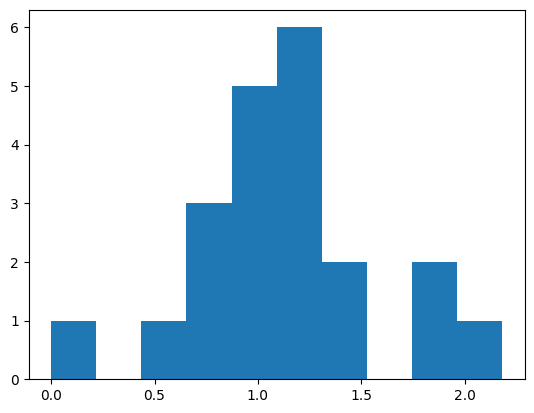

In [10]:
plt.hist(df_fred_fdic['Noncurrent Loan Rate - Loans to Individuals'])

In [12]:
X = df_fred_fdic[['Net Charge-Off Rate - C&I Loans', 'Problem Institutions', 'Net Charge-Off Rate - Loans to Individuals', 'HWI', 'CES3000000008', 'Noncurrent Loan Rate - Real Estate Loans', 'T5YFFM']
]
y = df_fred_fdic['Noncurrent Loan Rate - Loans to Individuals'] > 1
_, pls_score = run_plsr(X, y, clf=True)
print(f"\nPartial Least-Squares Logistic Regression: {'R²'}={pls_score:.4f}")

  (PLSR: classification detected, using PCA+Logistic as equivalent)

Partial Least-Squares Logistic Regression: R²=0.7600


In [ ]:
def run_plsr(X, y, clf=False, n_components=None):
    n_components = n_components or min(len(X.columns), 12)
    scoring = 'accuracy' if clf else 'r2'

    if clf:
        # PLS doesn't support classification natively — use PCA + Logistic instead
        print("  (PLSR: classification detected, using PCA+Logistic as equivalent)")
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_components)),
            ('clf', LogisticRegression(max_iter=1000))
        ])
    else:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pls', PLSRegression(n_components=n_components))
        ])

    score = cross_val_score(pipe, X, y, cv=5, scoring=scoring).mean()
    pipe.fit(X, y)
    return pipe, score

C:\Users\romus\AppData\Local\Temp\ipykernel_22084\1208652888.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


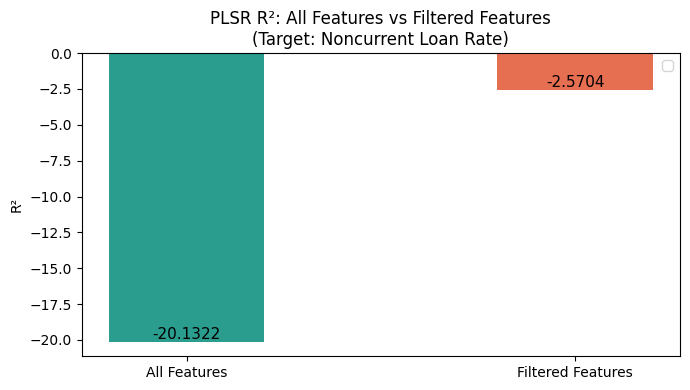

In [ ]:
X = df_fred_fdic.drop(columns='Noncurrent Loan Rate - Loans to Individuals')
X_filtered = df_fred_fdic[['Net Charge-Off Rate - C&I Loans', 'Problem Institutions', 'Net Charge-Off Rate - Loans to Individuals', 'HWI', 'CES3000000008', 'Noncurrent Loan Rate - Real Estate Loans', 'T5YFFM']
]
y = df_fred_fdic['Noncurrent Loan Rate - Loans to Individuals']
_, pls_score = run_plsr(X, y)
_, pls_score_filtered = run_plsr(X_filtered, y)
# print(f"\nPartial Least-Squares Logistic Regression: {'R²'}={pls_score:.4f}")
labels = ['All Features', 'Filtered Features']
scores = [pls_score, pls_score_filtered]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, scores, color=['#2a9d8f', '#e76f51'], width=0.4)

# Annotate bars with score values
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('R²')
ax.set_title('PLSR R²: All Features vs Filtered Features\n(Target: Noncurrent Loan Rate)')
# ax.set_ylim(0, 1.05)
# ax.axhline(round(y.mean(), 1), linestyle='--', color='gray', linewidth=0.8, label=f'Baseline {round(y.mean(), 1)}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
run_plsr(cred_X, df_credit['loan_status'].astype(int), "df_credit (loan_status)")

  (PLSR: classification detected, using PCA+Logistic as equivalent)


(Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=12)),
                 ('clf', LogisticRegression(max_iter=1000))]),
 0.8473877716559848)

# Homework 5

In [ ]:
# 'person_emp_length', 'person_income'

In [4]:
cred_X = df_credit[['loan_percent_income', 'loan_int_rate']]
cred_Y = df_credit['loan_status']
scaler = StandardScaler()
cred_X_sc = scaler.fit_transform(cred_X)
clf = svm.SVC()
clf.fit(cred_X_sc, cred_Y)

SVC()

C:\Users\romus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\inspection\_plot\decision_boundary.py:194: UserWarning: The following kwargs were not used by contour: 'multiclass_colors'
  self.surface_ = plot_func(self.xx0, self.xx1, self.response, **kwargs)


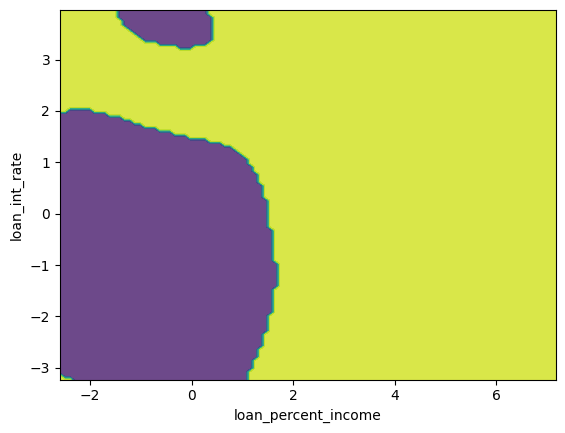

In [ ]:
DecisionBoundaryDisplay.from_estimator(
        clf,
        cred_X_sc,
        response_method="predict",
        multiclass_colors="coolwarm",
        alpha=0.8,
        xlabel=cred_X.columns[0],
        ylabel=cred_X.columns[1]
    )
# svcp = clf.predict(cred_X_sc)
# plt.plot(cred_Y, svcp)

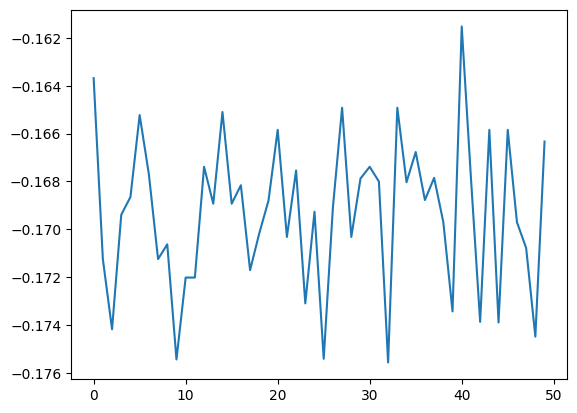

In [9]:
svc_scores = cross_val_score(clf, cred_X_sc, cred_Y, scoring='neg_mean_absolute_error', cv=RepeatedKFold(), n_jobs=-1)
plt.plot(svc_scores)

(array([ 5.,  4.,  3.,  7., 10., 10.,  5.,  4.,  1.,  1.]),
 array([-0.1755631 , -0.17415921, -0.17275532, -0.17135143, -0.16994755,
        -0.16854366, -0.16713977, -0.16573588, -0.164332  , -0.16292811,
        -0.16152422]),
 <BarContainer object of 10 artists>)

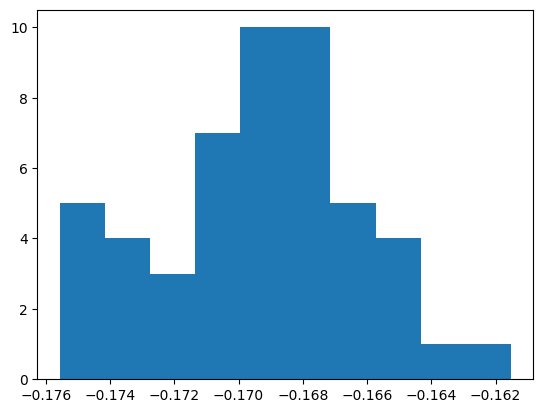

In [10]:
plt.hist(svc_scores)

# Homework 6

In [107]:
def tune_and_evaluate(model, param_grid, X_subset, y, n_splits=5, n_repeats=5, n_iter=20, label="Model", scoring='neg_mean_absolute_error', random_state=77):
    '''Scoring must be a list of one or more metrics'''
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)

    kfold = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
   
    if scoring == 'neg_mean_absolute_error':
        searcher = RandomizedSearchCV(model, param_grid, scoring=scoring,
                                    cv=3, n_iter=n_iter, n_jobs=-1,
                                    random_state=random_state, verbose=1)
        searcher.fit(X_scaled, y)
        best_params = searcher.best_params_
        print(f"\n{label} — Best Params: {best_params}")

        best_model = searcher.best_estimator_
        scores = cross_val_score(best_model, X_scaled, y, scoring=scoring, cv=kfold, n_jobs=-1)
        mae_scores = -scores
        print(f"CV MAE mean: {mae_scores.mean():,.3f} // Std: {mae_scores.std():,.3f}")
        return best_params, mae_scores
    else:
        scores = []
        for i, s in enumerate(scoring):
            searcher = RandomizedSearchCV(model, param_grid, scoring=scoring[i],
                                        cv=3, n_iter=n_iter, n_jobs=-1,
                                        random_state=random_state, verbose=1)

            searcher.fit(X_scaled, y)
            best_params = searcher.best_params_
            print(f"\n{label} — Best Params: {best_params}")

            best_model = searcher.best_estimator_
            scores.append(cross_val_score(best_model, X_scaled, y, scoring=s, cv=kfold, n_jobs=-1))
            print(f"{scoring[i]} mean: {scores[i].mean():,.3f} // Std: {scores[i].std():,.3f}")
        return best_params, scores

In [114]:
cred_X = pd.get_dummies(df_credit).drop(columns='loan_status')
cred_y = df_credit['loan_status']
cred_X_train, cred_X_test, cred_y_train, cred_y_test = train_test_split(cred_X, cred_y, test_size=0.3, random_state=1)

In [168]:
dt_params = {
    'max_depth':        [3, 5, 10, 15, 20, None],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features':     ['sqrt', 'log2', None]
}
clf = DecisionTreeClassifier()
clf.fit(cred_X_train, cred_y_train)
preds = clf.predict(cred_X_test)
display(confusion_matrix(cred_y_test, preds))
display(accuracy_score(cred_y_test, preds))
display(f1_score(cred_y_test, preds))
dt_best_params, dt_scores = tune_and_evaluate(DecisionTreeClassifier(), dt_params, cred_X_train, cred_y_train, scoring=['accuracy', 'f1'])

array([[7037,  595],
       [ 445, 1646]], dtype=int64)

0.8930371284582947

0.7599261311172668

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Model — Best Params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15}
accuracy mean: 0.917 // Std: 0.004
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Model — Best Params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15}
f1 mean: 0.791 // Std: 0.011


In [167]:
rf_params = {
    'n_estimators'      : np.arange(125, 250, 25),
    'max_depth'         : range(6, 16, 2),
    'max_features'      : [13],
    'min_samples_split' : range(4, 8),
    'min_samples_leaf'  : range(3, 15, 3),
}
rf = RandomForestClassifier()
rf.fit(cred_X_train, cred_y_train)
preds = rf.predict(cred_X_test)
display(confusion_matrix(cred_y_test, preds))
display(f1_score(cred_y_test, preds))
rf_best_params, rf_scores = tune_and_evaluate(RandomForestClassifier(), rf_params, cred_X_train, cred_y_train, scoring=['accuracy', 'f1'])

array([[7572,   60],
       [ 541, 1550]], dtype=int64)

0.837611456363145

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Model — Best Params: {'n_estimators': 225, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 13, 'max_depth': 12}
accuracy mean: 0.929 // Std: 0.003
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Model — Best Params: {'n_estimators': 225, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 13, 'max_depth': 12}
f1 mean: 0.812 // Std: 0.009


In [ ]:
rf = RandomForestClassifier()
rf.fit(cred_X_train, cred_y_train)
preds = rf.predict(cred_X_test)
accuracy_score(cred_y_test, preds)
low = cred_y_test.min()
hi = cred_y_test.max()
best_params_preds_rf = RandomForestClassifier(**rf_best_params).fit(cred_X_train, cred_y_train).predict(cred_X_test)
best_params_preds_dt = DecisionTreeClassifier(**dt_best_params).fit(cred_X_train, cred_y_train).predict(cred_X_test)
# plot baseline preds vs preds of model with rf_best_params and with dt_best_params to gauge overfitting

0.9387020466934074

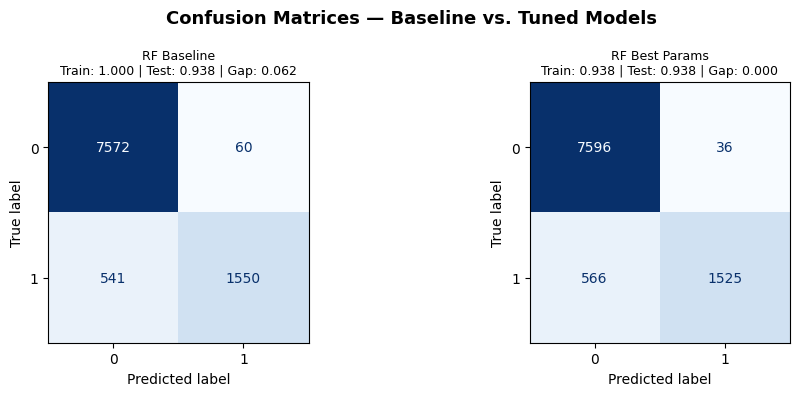

In [172]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# ── Fit once, store model + preds together ────────────────────────────────
rf_baseline = rf  # already fitted above

rf_tuned = RandomForestClassifier(**rf_best_params).fit(cred_X_train, cred_y_train)

models = {
    "RF Baseline":    rf_baseline,
    "RF Best Params": rf_tuned,
}

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Confusion Matrices — Baseline vs. Tuned Models", fontsize=13, fontweight="bold")

for ax, (label, model) in zip(axes, models.items()):
    train_acc = accuracy_score(cred_y_train, model.predict(cred_X_train))
    test_acc  = accuracy_score(cred_y_test,  model.predict(cred_X_test))
    gap       = train_acc - test_acc

    cm = confusion_matrix(cred_y_test, model.predict(cred_X_test))
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap="Blues")

    ax.set_title(
        f"{label}\nTrain: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

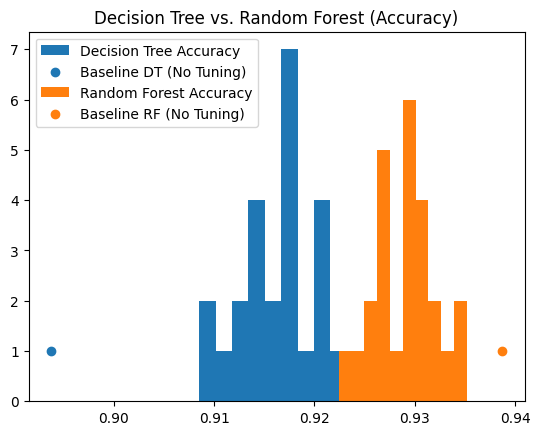

In [147]:
ax = plt.subplot()
ax.hist(dt_scores[0], label='Decision Tree Accuracy')
ax.scatter(0.8937570708629023, 1, label='Baseline DT (No Tuning)')
ax.hist(rf_scores[0], label='Random Forest Accuracy')
ax.scatter(0.9387020466934074, 1, label='Baseline RF (No Tuning)')
ax.set_title('Decision Tree vs. Random Forest (Accuracy)')
ax.legend()

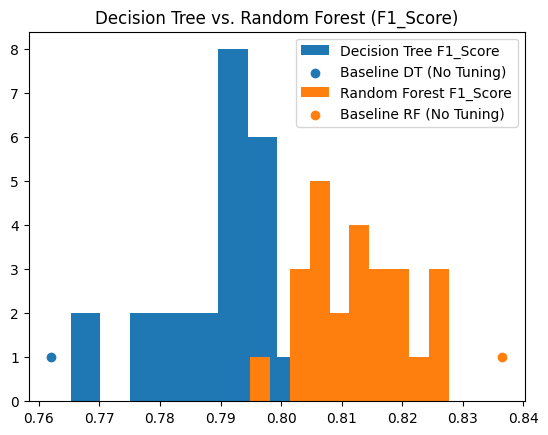

In [146]:
ax = plt.subplot()
ax.hist(dt_scores[1], label='Decision Tree F1_Score')
ax.scatter(0.7620363971435153, 1, label='Baseline DT (No Tuning)')
ax.hist(rf_scores[1], label='Random Forest F1_Score')
ax.scatter(0.8364813815434431, 1, label='Baseline RF (No Tuning)')
ax.set_title('Decision Tree vs. Random Forest (F1_Score)')
ax.legend()

In [164]:
rf_params = {
    'n_estimators'      : np.arange(15,50,5),
    'max_depth'         : range(1, 15),
    'min_samples_split' : range(2,6),
    'min_samples_leaf'  : range(2, 15),
}

fred_X = df_fred.dropna(how='any')[['HOUSTS', 'HOUST', 'HOUSTW', 'IPDCONGD', 'HOUSTMW', 
'HOUSTNE', 'IPMAT', 'IPDMAT', 'IPFUELS', 'IPNCONGD', 'RPI']]
fred_y = df_fred.dropna(how='any')['DTCTHFNM']
fred_X_train, fred_X_test, fred_y_train, fred_y_test = train_test_split(fred_X, fred_y, test_size=0.3, random_state=1)

rf = RandomForestRegressor()
rf.fit(fred_X_train, fred_y_train)
preds = rf.predict(fred_X_test)
print(mean_absolute_error(fred_y_test, preds))
rf_best_params, rf_scores = tune_and_evaluate(RandomForestRegressor(), rf_params, fred_X_train, fred_y_train)

9745.298103370747
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Model — Best Params: {'n_estimators': 40, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 14}
CV MAE mean: 11,560.981 // Std: 1,900.794
